# Análisis de la procedencia de los viajeros — INE · EOH (Sprint 4)

**StaySpain · Equip 34 · 20/07/2026**

Este notebook responde a una única pregunta del Sprint 4: **¿de dónde proceden los viajeros**
de los mercados donde opera StaySpain? Se apoya *exclusivamente* en la **Encuesta de Ocupación
Hotelera (EOH)** del INE, ya limpia y unificada en `clean_dataset_INE_EOH_20_07_2026.csv`, que
apila en formato largo las cuatro tablas de la encuesta:

| tabla | qué aporta a la procedencia | nivel |
|-------|-----------------------------|-------|
| **2078** | Residentes en España vs Extranjero, por **punto turístico** | Barcelona, Madrid, Valencia, Málaga, Sevilla |
| **2039** | Residentes en España vs Extranjero, por **zona turística** | Mallorca, Menorca, Costa Brava (Girona) |
| **2074** | Nacional vs Extranjero por **CCAA** y **España** | 5 CCAA + total nacional |
| **2069** | **De qué CCAA** procede el viajero nacional, por **provincia** | 7 provincias de los mercados |

**Decisiones de análisis heredadas del sprint** (ver `analisis_INE_EOH_20_07_2026.py`):
- **Año de referencia: 2025** (último completo). El dataset trae 1999–2026, aquí se filtra a 2025.
- El **extranjero se trata como un único agregado** (sin desglose por país): ya viene así en la EOH.
- El **nacional sí se desglosa por CCAA de procedencia** (tabla 2069, nivel provincia).
- Mallorca y Menorca comparten provincia (Illes Balears) → su **origen nacional es el mismo dato**.

> **Carga robusta (requisito del encargo).** El notebook funciona de las dos formas sin tocar
> nada: con el **dataset único** `clean_dataset_INE_EOH_20_07_2026.csv`, o con los **4 archivos
> divididos por tabla** `EOH_2039_clean_…`, `EOH_2069_clean_…`, `EOH_2074_clean_…`,
> `EOH_2078_clean_…` (mismos nombres que los raw pero con `clean`). Detecta automáticamente
> cuáles existen. Hay una celda opcional para generar la división por si se decide dividir.

## 1 · Configuración y carga robusta (1 archivo **o** 4)

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

# --- año de referencia del sprint --------------------------------------------
ANIO = 2025

# --- nombres de archivo -------------------------------------------------------
TABLAS        = ["2039", "2069", "2074", "2078"]
NOMBRE_UNICO  = "clean_dataset_INE_EOH_20_07_2026.csv"
def NOMBRE_DIV(t):                      # mismos nombres que los raw pero con 'clean'
    return f"EOH_{t}_clean_20_07_2026.csv"

# columnas numéricas que en el CSV vienen con coma decimal y separador de miles '.'
COLS_NUM = ["valor", "estancia_media", "pct_nacional", "pct_extranjero",
            "total_nacional_provincia", "valor_estimado_origen", "estancia_media_origen",
            "indice_estacional_base_100", "pct_mes_demanda_2023_2025"]
COLS_BOOL = ["sin_dato", "es_dato_no_publicado", "provisional", "serie_enlazada",
             "es_demanda_destino", "es_procedencia_nacional", "es_total_territorial",
             "ambito_sprint4"]

def _a_numero(s):
    """'179.154,0' -> 179154.0 ; '.' / '' -> NaN"""
    return pd.to_numeric(
        s.astype(str).str.replace(".", "", regex=False).str.replace(",", ".", regex=False),
        errors="coerce")

def _leer(path):
    return pd.read_csv(path, sep=";", encoding="utf-8-sig", dtype=str)

def encontrar_data(inicio=None):
    """Busca hacia arriba una carpeta Data que contenga los datos INE EOH."""
    inicio = Path(inicio or Path.cwd()).resolve()
    for base in [inicio, *inicio.parents]:
        for cand in (base / "Data", base / "Equip_34" / "Data"):
            if cand.is_dir() and (
                (cand / NOMBRE_UNICO).exists()
                or all((cand / NOMBRE_DIV(t)).exists() for t in TABLAS)):
                return cand
    raise FileNotFoundError("No encuentro la carpeta Data con los datos INE EOH.")

def cargar_ine_eoh(data_dir=None):
    """Carga el dataset funcione como funcione: 4 archivos divididos o 1 único.

    Devuelve (df, modo). Prioriza los 4 divididos si están TODOS presentes;
    si no, usa el dataset único. El DataFrame resultante es idéntico en ambos casos."""
    data_dir = Path(data_dir) if data_dir else encontrar_data()
    divididos = [data_dir / NOMBRE_DIV(t) for t in TABLAS]
    if all(p.exists() for p in divididos):
        modo = f"DIVIDIDO · 4 archivos ({', '.join(NOMBRE_DIV(t) for t in TABLAS)})"
        df = pd.concat([_leer(p) for p in divididos], ignore_index=True)
    elif (data_dir / NOMBRE_UNICO).exists():
        modo = f"ÚNICO · {NOMBRE_UNICO}"
        df = _leer(data_dir / NOMBRE_UNICO)
    else:
        raise FileNotFoundError(f"En {data_dir} no hay ni el único ni los 4 divididos.")

    for c in COLS_NUM:
        if c in df.columns:
            df[c] = _a_numero(df[c])
    for c in ("anio", "mes"):
        df[c] = pd.to_numeric(df[c], errors="coerce").astype("Int64")
    for c in COLS_BOOL:
        if c in df.columns:
            df[c] = df[c].map({"True": True, "False": False}).fillna(False)
    return df, modo

DATA = encontrar_data()
df, MODO = cargar_ine_eoh(DATA)
print(f"Carpeta de datos : {DATA}")
print(f"Modo de carga    : {MODO}")
print(f"Filas · columnas : {len(df):,} · {df.shape[1]}")
print(f"Tablas cargadas  : {dict(sorted(df['tabla'].value_counts().items()))}")
print(f"Rango de años    : {int(df['anio'].min())}–{int(df['anio'].max())}")

Carpeta de datos : E:\informacion y documentos\Curso analisis de datos IT Academy\Simulador empresarial\ProjecteData\Equip_34\Data
Modo de carga    : ÚNICO · clean_dataset_INE_EOH_20_07_2026.csv
Filas · columnas : 118,224 · 48
Tablas cargadas  : {'2039': 6912, '2069': 76320, '2074': 15120, '2078': 19872}
Rango de años    : 2023–2025


### 1·bis (opcional) — dividir el dataset único en 4 archivos por tabla

Solo si el equipo decide **dividir**. Ejecutar esta celda una vez crea
`EOH_2039_clean_…`, `EOH_2069_clean_…`, `EOH_2074_clean_…`, `EOH_2078_clean_…`
en la misma carpeta `Data`, con **formato idéntico** al original (`;`, coma decimal,
UTF-8 con BOM) para que la carga los lea igual. A partir de ese momento `cargar_ine_eoh`
usará automáticamente los 4. Para volver al único, basta con borrarlos.

In [2]:
HACER_DIVISION = False   # <-- pon True y ejecuta para generar los 4 archivos

def dividir_en_4(data_dir=None):
    """Parte el CSV único en 4 (uno por tabla) conservando el formato exacto."""
    data_dir = Path(data_dir) if data_dir else encontrar_data()
    crudo = _leer(data_dir / NOMBRE_UNICO)              # se relee como texto: round-trip exacto
    creados = []
    for t in TABLAS:
        sub = crudo[crudo["tabla"] == t]
        destino = data_dir / NOMBRE_DIV(t)
        sub.to_csv(destino, sep=";", index=False, encoding="utf-8-sig")
        creados.append((destino.name, len(sub)))
    return creados

if HACER_DIVISION:
    for nombre, n in dividir_en_4(DATA):
        print(f"  creado {nombre:<32} {n:>9,} filas")
    df, MODO = cargar_ine_eoh(DATA)            # recarga desde los 4 recién creados
    print(f"\nRecargado en modo: {MODO}")
else:
    print("División desactivada (HACER_DIVISION = False). Se usa el dataset único.")

División desactivada (HACER_DIVISION = False). Se usa el dataset único.


## 2 · Preparación: subconjunto 2025 y utilidades

In [3]:
# Orden y etiquetas de los 8 mercados (Girona = Costa Brava, no la ciudad de interior)
ORDEN_MERCADO = ["Mallorca", "Barcelona", "Madrid", "Girona", "Sevilla",
                 "Menorca", "Valencia", "Málaga"]
ETIQUETA_MERCADO = {"Girona": "Costa Brava (Girona)"}
def etq(m):                       # nombre para mostrar
    return ETIQUETA_MERCADO.get(m, m)

MESES_ORD = ["ene", "feb", "mar", "abr", "may", "jun",
             "jul", "ago", "sep", "oct", "nov", "dic"]
NUM_A_MES = {i + 1: m for i, m in enumerate(MESES_ORD)}

# nombre legible de la CCAA de origen a partir de categoria_key (tabla 2069)
def titulo_ccaa(clave):
    especiales = {"balears, illes": "Illes Balears", "rioja, la": "La Rioja",
                  "madrid, comunidad de": "Madrid", "murcia, region de": "Murcia",
                  "navarra, comunidad foral de": "Navarra", "castilla y leon": "Castilla y León",
                  "castilla - la mancha": "Castilla-La Mancha", "asturias, principado de": "Asturias",
                  "pais vasco": "País Vasco", "comunitat valenciana": "C. Valenciana",
                  "cataluna": "Cataluña", "aragon": "Aragón", "region de murcia": "Murcia",
                  "andalucia": "Andalucía"}
    return especiales.get(clave, clave.title())

def suma(s):                      # suma que respeta el secreto estadístico ('.' del INE = NaN, no 0)
    return s.sum(min_count=1)

# --- render de tablas legibles (HTML con líneas) en vez de print(to_string) ---
from IPython.display import display

def tabla_estilizada(tdf, titulo=None, fmt=None, na="s.d.", ocultar_indice=False, align="right"):
    """Devuelve un pandas Styler con bordes, cabecera sombreada y título, para que
    la tabla se lea bien en el notebook. `fmt` puede ser str ('{:.1f}%') o dict por columna."""
    sty = tdf.style.format(na_rep=na) if fmt is None else tdf.style.format(fmt, na_rep=na)
    if ocultar_indice:
        sty = sty.hide(axis="index")
    # Tabla AUTOCONTENIDA: fondo claro + texto oscuro EXPLÍCITO en todas las celdas y en el
    # título, para que se lea igual en tema claro u oscuro de VSCode (no hereda colores del tema).
    sty = sty.set_table_styles([
        {"selector": "", "props": [("border-collapse", "collapse"),
                                    ("font-family", "system-ui, 'Segoe UI', sans-serif"),
                                    ("font-size", "12px"), ("border", "1px solid #c3c2b7")]},
        {"selector": "th, td", "props": [("border", "1px solid #c3c2b7"), ("padding", "5px 10px"),
                                          ("text-align", align), ("background-color", "#ffffff"),
                                          ("color", "#111111")]},
        {"selector": "thead th", "props": [("background-color", "#dfe6ef"), ("color", "#0b0b0b"),
                                            ("font-weight", "600"), ("text-align", "center")]},
        {"selector": "th.row_heading", "props": [("background-color", "#eef0f2"), ("color", "#0b0b0b"),
                                                  ("text-align", "left"), ("font-weight", "600")]},
        {"selector": "caption", "props": [("caption-side", "top"), ("text-align", "left"),
                                           ("font-weight", "700"), ("font-size", "13px"),
                                           ("color", "#0b0b0b"), ("background-color", "#dfe6ef"),
                                           ("padding", "6px 10px"), ("border", "1px solid #c3c2b7"),
                                           ("border-bottom", "none")]},
    ])
    return sty.set_caption(titulo) if titulo else sty

ref = df[df["anio"] == ANIO]
print(f"Filas del año de referencia {ANIO}: {len(ref):,}")
print("Mercados detectados:", sorted(ref.loc[ref['mercado_stayspain'].notna(), 'mercado_stayspain'].unique()))

Filas del año de referencia 2025: 39,408
Mercados detectados: ['Barcelona', 'Girona', 'Madrid', 'Mallorca', 'Menorca', 'Málaga', 'Sevilla', 'Valencia']


## 3 · Procedencia global de cada mercado — **nacional vs extranjero**

De las tablas **2078** (puntos turísticos) y **2039** (zonas turísticas). Se agregan las
**pernoctaciones** y los **viajeros** de 2025 por mercado y se reparte entre *Residentes en
España* y *Residentes en el Extranjero*. `sin_dato` del INE (`.`) se trata como ausente, no cero.

In [4]:
mk = ref[ref["mercado_stayspain"].notna()].copy()

def reparto_procedencia(sub, metrica):
    d = sub[sub["metrica"] == metrica]
    piv = d.pivot_table(index="mercado_stayspain", columns="categoria_key",
                        values="valor", aggfunc=suma)
    nac = piv.get("residentes en espana")
    ext = piv.get("residentes en el extranjero")
    tot = nac.add(ext, fill_value=0)
    return pd.DataFrame({
        f"{metrica} nac (M)": nac / 1e6,
        f"{metrica} ext (M)": ext / 1e6,
        f"% nacional ({metrica})": nac / tot * 100,
        f"% extranjero ({metrica})": ext / tot * 100,
    })

p_pern = reparto_procedencia(mk, "pernoctaciones")
p_viaj = reparto_procedencia(mk, "viajeros")
P1 = p_pern.join(p_viaj).reindex(ORDEN_MERCADO).round(1)
P1.index = [etq(m) for m in P1.index]
P1.index.name = "mercado"

display(tabla_estilizada(
    P1[["% nacional (pernoctaciones)", "% extranjero (pernoctaciones)",
        "% nacional (viajeros)", "% extranjero (viajeros)"]],
    "Procedencia por mercado — % nacional vs extranjero (2025)", fmt="{:.1f}%"))
display(tabla_estilizada(
    P1[["pernoctaciones nac (M)", "pernoctaciones ext (M)",
        "viajeros nac (M)", "viajeros ext (M)"]],
    "Volumen por mercado — millones de pernoctaciones y viajeros (2025)", fmt="{:.1f}"))

,% nacional (pernoctaciones),% extranjero (pernoctaciones),% nacional (viajeros),% extranjero (viajeros)
mercado,,,,
Mallorca,6.3%,93.7%,9.5%,90.5%
Barcelona,12.3%,87.7%,17.2%,82.8%
Madrid,34.0%,66.0%,41.3%,58.7%
Costa Brava (Girona),28.2%,71.8%,37.9%,62.1%
Sevilla,30.4%,69.6%,37.4%,62.6%
Menorca,17.4%,82.6%,24.5%,75.5%
Valencia,34.1%,65.9%,43.9%,56.1%
Málaga,30.8%,69.2%,35.9%,64.1%


,pernoctaciones nac (M),pernoctaciones ext (M),viajeros nac (M),viajeros ext (M)
mercado,,,,
Mallorca,3.1,46.2,0.9,8.5
Barcelona,2.7,19.0,1.5,7.4
Madrid,7.3,14.1,4.3,6.1
Costa Brava (Girona),3.5,8.8,1.5,2.5
Sevilla,2.0,4.6,1.2,2.0
Menorca,0.8,4.0,0.2,0.6
Valencia,1.7,3.2,0.9,1.2
Málaga,1.2,2.6,0.7,1.2


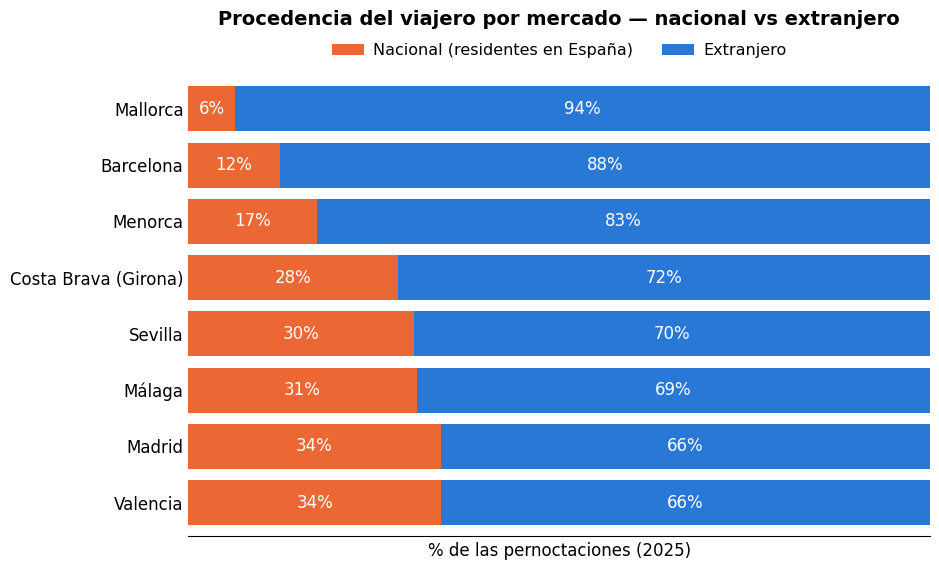

In [5]:
# --- gráfico: barras 100% apiladas, % de pernoctaciones nacional vs extranjero ---
# Colores de identidad fija (paleta validada): naranja = nacional, azul = extranjero.
COL_NAC, COL_EXT = "#eb6834", "#2a78d6"
orden_plot = P1.sort_values("% extranjero (pernoctaciones)")   # más internacional arriba
y = np.arange(len(orden_plot))
nac = orden_plot["% nacional (pernoctaciones)"].values
ext = orden_plot["% extranjero (pernoctaciones)"].values

fig, ax = plt.subplots(figsize=(9.5, 5.8))
ax.barh(y, nac, color=COL_NAC, label="Nacional (residentes en España)", height=0.8)
ax.barh(y, ext, left=nac, color=COL_EXT, label="Extranjero", height=0.8)
for yi, (n, e) in enumerate(zip(nac, ext)):
    if n >= 6:  ax.text(n / 2, yi, f"{n:.0f}%", va="center", ha="center", color="white", fontsize=12)
    if e >= 6:  ax.text(n + e / 2, yi, f"{e:.0f}%", va="center", ha="center", color="white", fontsize=12)
ax.set_yticks(y); ax.set_yticklabels(orden_plot.index, fontsize=12)
ax.set_xlim(0, 100); ax.set_xlabel("% de las pernoctaciones (2025)", fontsize=12)
ax.set_xticks([])                           # los % ya están en las barras
ax.set_ylim(-0.6, len(orden_plot) - 0.4)    # barras a toda la altura
ax.set_title("Procedencia del viajero por mercado — nacional vs extranjero",
             loc="center", fontsize=14, weight="bold", pad=36)
# leyenda centrada, justo debajo del título (libera el ancho para barras más grandes)
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.005), ncol=2, frameon=False,
          fontsize=11.5, columnspacing=1.8, handletextpad=0.6)
for s in ("top", "right", "left"): ax.spines[s].set_visible(False)
ax.tick_params(length=0)
plt.tight_layout(); plt.show()

## 4 · Procedencia a nivel **comunidad autónoma** y **España** (tabla 2074)

Contexto de destino agregado: reparto nacional/extranjero de las 5 CCAA donde opera StaySpain
y del total nacional. Sirve para comparar cada mercado con su comunidad (¿es más internacional
el mercado que su CCAA?).

In [6]:
t74 = ref[ref["tabla"] == "2074"]

def reparto_74(sub, metrica):
    d = sub[sub["metrica"] == metrica]
    piv = d.pivot_table(index="geo", columns="categoria_key", values="valor", aggfunc=suma)
    nac, ext = piv.get("residentes en espana"), piv.get("residentes en el extranjero")
    tot = nac.add(ext, fill_value=0)
    return pd.DataFrame({f"{metrica} (M)": tot / 1e6,
                         f"% nacional ({metrica})": nac / tot * 100,
                         f"% extranjero ({metrica})": ext / tot * 100})

ccaa = t74[t74["nivel_geo"] == "ccaa"]
esp  = t74[t74["nivel_geo"] == "nacional"]

P2_ccaa = reparto_74(ccaa, "pernoctaciones").join(reparto_74(ccaa, "viajeros")).round(1)
P2_esp  = reparto_74(esp,  "pernoctaciones").join(reparto_74(esp,  "viajeros")).round(1)
P2_esp.index = ["España (total nacional)"]
ORDEN_CCAA = ["Cataluña", "Balears, Illes", "Andalucía", "Madrid, Comunidad de", "Comunitat Valenciana"]
P2 = pd.concat([P2_ccaa.reindex([c for c in ORDEN_CCAA if c in P2_ccaa.index]), P2_esp])
P2.index.name = "territorio"

display(tabla_estilizada(
    P2[["pernoctaciones (M)", "% nacional (pernoctaciones)", "% extranjero (pernoctaciones)",
        "% nacional (viajeros)", "% extranjero (viajeros)"]],
    "Procedencia por CCAA y España (2025)",
    fmt={"pernoctaciones (M)": "{:.1f}",
         "% nacional (pernoctaciones)": "{:.1f}%", "% extranjero (pernoctaciones)": "{:.1f}%",
         "% nacional (viajeros)": "{:.1f}%", "% extranjero (viajeros)": "{:.1f}%"}))

,pernoctaciones (M),% nacional (pernoctaciones),% extranjero (pernoctaciones),% nacional (viajeros),% extranjero (viajeros)
territorio,,,,,
Cataluña,60.6,27.6%,72.4%,35.4%,64.6%
"Balears, Illes",63.4,8.1%,91.9%,11.9%,88.1%
Andalucía,57.2,44.4%,55.6%,52.1%,47.9%
"Madrid, Comunidad de",27.6,41.5%,58.5%,47.7%,52.3%
Comunitat Valenciana,31.6,47.4%,52.6%,54.4%,45.6%
España (total nacional),366.4,33.2%,66.8%,46.2%,53.8%


## 5 · Todos los orígenes del viajero — extranjero unificado + todas las CCAA

Aquí se abre la procedencia **completa**: el **extranjero como un único agregado** y **todas
las comunidades autónomas de origen** del viajero nacional (tabla 2069), tanto las que
coinciden con regiones donde opera StaySpain como las que no. Para cada mercado se reparte el
100 % de sus **viajeros** entre esos orígenes:

- **Extranjero** = viajeros residentes en el extranjero del mercado (tablas 2078 / 2039).
- **cada CCAA** = viajeros nacionales del mercado repartidos por las cuotas de origen de la 2069
  (`valor_estimado_origen`, ponderado por volumen de viajeros de cada mes).

La columna **Total 8 mercados** pondera por el volumen de viajeros de cada mercado: es el
reparto de origen del conjunto de la operación de StaySpain. La columna **StaySpain** marca con
`sí` las CCAA donde la empresa opera.

> Nivel provincia en la 2069: Mallorca y Menorca comparten *Illes Balears* (mismas cuotas
> nacionales). El extranjero no se desglosa por país (decisión de análisis del sprint).

In [7]:
orig = ref[(ref["tabla"] == "2069") & (ref["es_procedencia_nacional"]) &
           (ref["metrica"] == "viajeros") & (ref["categoria_key"] != "total")].copy()

# peso = viajeros residentes estimados de cada CCAA de origen (ya ponderado por mes)
mezcla = (orig.groupby(["provincia_referencia", "categoria_key"])["valor_estimado_origen"]
              .sum(min_count=1).rename("estimado").reset_index())
mezcla["ccaa_origen"] = mezcla["categoria_key"].map(titulo_ccaa)
total_prov = mezcla.groupby("provincia_referencia")["estimado"].transform("sum")
mezcla["pct"] = mezcla["estimado"] / total_prov * 100

# mercado -> provincia (Mallorca y Menorca comparten Illes Balears)
MERCADO_PROV = {"Barcelona": "Barcelona", "Madrid": "Madrid", "Valencia": "Valencia/València",
                "Málaga": "Málaga", "Sevilla": "Sevilla", "Girona": "Girona",
                "Mallorca": "Balears, Illes", "Menorca": "Balears, Illes"}

filas = []
for m in ORDEN_MERCADO:
    prov = MERCADO_PROV[m]
    top = (mezcla[mezcla["provincia_referencia"] == prov]
           .sort_values("pct", ascending=False).head(4))
    filas.append({"mercado": etq(m), "provincia INE": prov,
                  "top CCAA emisoras nacionales":
                      " · ".join(f"{r.ccaa_origen} {r.pct:.1f}%" for r in top.itertuples())})
P3 = pd.DataFrame(filas)
display(tabla_estilizada(
    P3, "Resumen — principales CCAA emisoras del viajero nacional por mercado (2025, tabla 2069)",
    ocultar_indice=True, align="left"))

mercado,provincia INE,top CCAA emisoras nacionales
Mallorca,"Balears, Illes",Illes Balears 32.4% · Cataluña 15.8% · Madrid 15.7% · C. Valenciana 8.2%
Barcelona,Barcelona,Cataluña 39.6% · Madrid 21.6% · C. Valenciana 7.5% · Andalucía 6.5%
Madrid,Madrid,Madrid 20.3% · Andalucía 15.2% · Cataluña 12.6% · C. Valenciana 9.8%
Costa Brava (Girona),Girona,Cataluña 77.3% · Madrid 5.8% · C. Valenciana 3.8% · País Vasco 2.4%
Sevilla,Sevilla,Andalucía 41.2% · Madrid 19.7% · Cataluña 7.9% · C. Valenciana 4.9%
Menorca,"Balears, Illes",Illes Balears 32.4% · Cataluña 15.8% · Madrid 15.7% · C. Valenciana 8.2%
Valencia,Valencia/València,Madrid 27.3% · C. Valenciana 23.3% · Cataluña 13.4% · Andalucía 8.4%
Málaga,Málaga,Andalucía 55.6% · Madrid 15.8% · Cataluña 4.7% · C. Valenciana 3.4%


In [8]:
# === TABLA COMPLETA: todos los orígenes (Extranjero unificado + todas las CCAA) ===
# viajeros nacionales / extranjeros por mercado (personas)
vt = (mk[mk["metrica"] == "viajeros"]
      .pivot_table(index="mercado_stayspain", columns="categoria_key", values="valor", aggfunc=suma))
vt_nac, vt_ext = vt["residentes en espana"], vt["residentes en el extranjero"]

# cuotas de origen nacional por provincia (2069) y lista de TODAS las CCAA de origen
cuota = mezcla.pivot_table(index="provincia_referencia", columns="ccaa_origen", values="pct")
ORIGENES_CCAA = sorted(mezcla["ccaa_origen"].unique())
STAYSPAIN_CCAA = {"Cataluña", "Illes Balears", "Andalucía", "Madrid", "C. Valenciana"}

# estimación de viajeros por (mercado x origen): Extranjero + cada CCAA
est_v = {}
for m in ORDEN_MERCADO:
    prov = MERCADO_PROV[m]
    fila = {"Extranjero": vt_ext.get(m, np.nan)}
    for c in ORIGENES_CCAA:
        sh = cuota.loc[prov, c] if (prov in cuota.index and c in cuota.columns) else np.nan
        fila[c] = vt_nac.get(m, np.nan) * sh / 100 if pd.notna(sh) else 0.0
    est_v[etq(m)] = fila
EST = pd.DataFrame(est_v).T                                  # filas=mercado, cols=origen (viajeros)

PCT = (EST.div(EST.sum(axis=1), axis=0) * 100).T             # filas=origen, cols=mercado (cada col=100)
PCT["Total 8 mercados"] = EST.sum(axis=0) / EST.values.sum() * 100

# orden: Extranjero arriba, luego CCAA por peso en el conjunto
orden_orig = ["Extranjero"] + (PCT.drop(index="Extranjero")["Total 8 mercados"]
                               .sort_values(ascending=False).index.tolist())
P5 = PCT.reindex(orden_orig).round(2)
P5.insert(0, "StaySpain", ["—"] + ["sí" if o in STAYSPAIN_CCAA else "—" for o in orden_orig[1:]])
P5.index.name = "origen"

cols_pct = [etq(m) for m in ORDEN_MERCADO] + ["Total 8 mercados"]
display(tabla_estilizada(
    P5[["StaySpain"] + cols_pct],
    "Todos los orígenes del viajero por mercado — % de viajeros (2025) · extranjero unificado",
    fmt={c: "{:.1f}%" for c in cols_pct}))

,StaySpain,Mallorca,Barcelona,Madrid,Costa Brava (Girona),Sevilla,Menorca,Valencia,Málaga,Total 8 mercados
origen,,,,,,,,,,
Extranjero,—,90.5%,82.8%,58.7%,62.1%,62.6%,75.5%,56.1%,64.1%,72.4%
Cataluña,sí,1.5%,6.8%,5.2%,29.2%,3.0%,3.9%,5.9%,1.7%,6.8%
Madrid,sí,1.5%,3.7%,8.4%,2.2%,7.4%,3.9%,12.0%,5.7%,5.0%
Andalucía,sí,0.8%,1.1%,6.3%,0.9%,15.4%,2.0%,3.7%,19.9%,4.4%
C. Valenciana,sí,0.8%,1.3%,4.0%,1.4%,1.9%,2.0%,10.2%,1.2%,2.4%
Illes Balears,sí,3.1%,0.5%,1.2%,0.5%,0.6%,8.0%,1.0%,0.6%,1.5%
País Vasco,—,0.3%,0.6%,2.0%,0.9%,0.8%,0.8%,0.9%,0.7%,1.0%
Castilla y León,—,0.2%,0.3%,2.2%,0.4%,1.2%,0.6%,1.5%,0.8%,0.9%
Galicia,—,0.3%,0.4%,2.1%,0.3%,0.8%,0.7%,0.9%,0.6%,0.9%


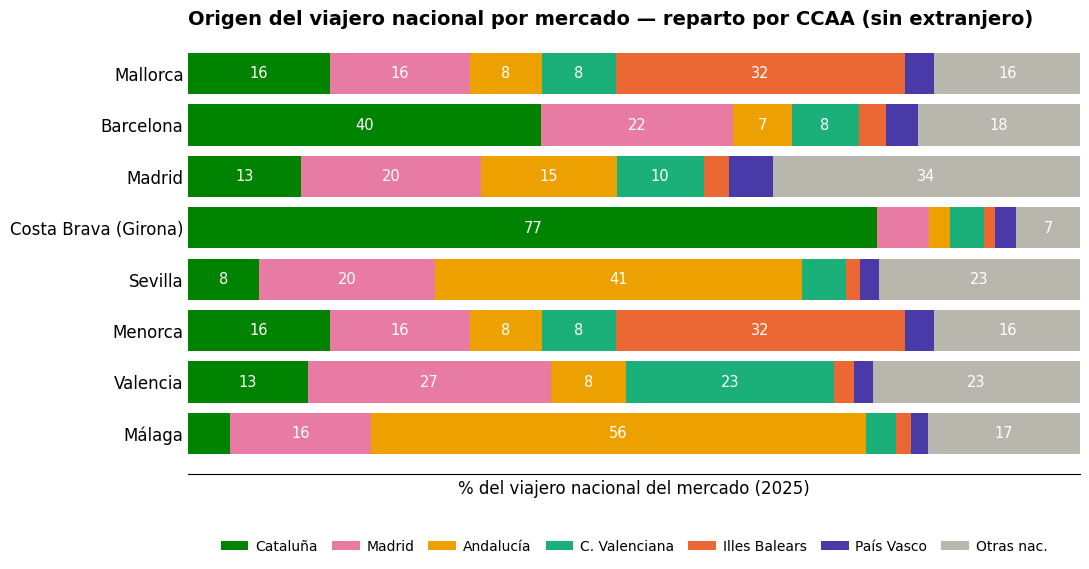

In [9]:
# --- gráfico 1: origen del viajero NACIONAL por mercado (solo CCAA, % de los nacionales) ---
# Sin extranjero: cada barra reparte el 100% de los VIAJEROS NACIONALES del mercado entre sus
# CCAA de origen (cuotas de la 2069, que suman 100 entre los residentes en España).
CAT = ["#008300", "#e87ba4", "#eda100", "#1baf7a", "#eb6834", "#4a3aa7"]   # CCAA nacionales
GRIS = "#b8b6ad"

top_nac = (mezcla.groupby("ccaa_origen")["estimado"].sum(min_count=1)
              .sort_values(ascending=False).head(6).index.tolist())
color_o = {c: CAT[i] for i, c in enumerate(top_nac)}
segmentos = top_nac + ["Otras nac."]

Mx = pd.DataFrame(index=[etq(m) for m in ORDEN_MERCADO], columns=segmentos, dtype=float)
for m in ORDEN_MERCADO:
    sub = mezcla[mezcla["provincia_referencia"] == MERCADO_PROV[m]]
    fila = etq(m)
    for c in top_nac:
        Mx.loc[fila, c] = sub.loc[sub["ccaa_origen"] == c, "pct"].sum()
    Mx.loc[fila, "Otras nac."] = 100 - Mx.loc[fila, top_nac].sum()

fig, ax = plt.subplots(figsize=(11, 5.8))
y = np.arange(len(Mx)); izq = np.zeros(len(Mx))
for c in segmentos:
    ax.barh(y, Mx[c].values, left=izq, color=color_o.get(c, GRIS), label=c, height=0.8)
    for yi, (v, x0) in enumerate(zip(Mx[c].values, izq)):
        if v >= 6:
            ax.text(x0 + v / 2, yi, f"{v:.0f}", va="center", ha="center", color="white", fontsize=10.5)
    izq += Mx[c].values
ax.set_yticks(y); ax.set_yticklabels(Mx.index, fontsize=12); ax.invert_yaxis()
ax.set_xlim(0, 100); ax.set_xlabel("% del viajero nacional del mercado (2025)", fontsize=12)
ax.set_xticks([])                           # los % ya están en las barras
ax.set_title("Origen del viajero nacional por mercado — reparto por CCAA (sin extranjero)",
             loc="left", fontsize=14, weight="bold")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=len(segmentos),
          frameon=False, fontsize=10, columnspacing=1.0, handletextpad=0.5)
for s in ("top", "right", "left"): ax.spines[s].set_visible(False)
ax.tick_params(length=0)
plt.tight_layout(); plt.show()

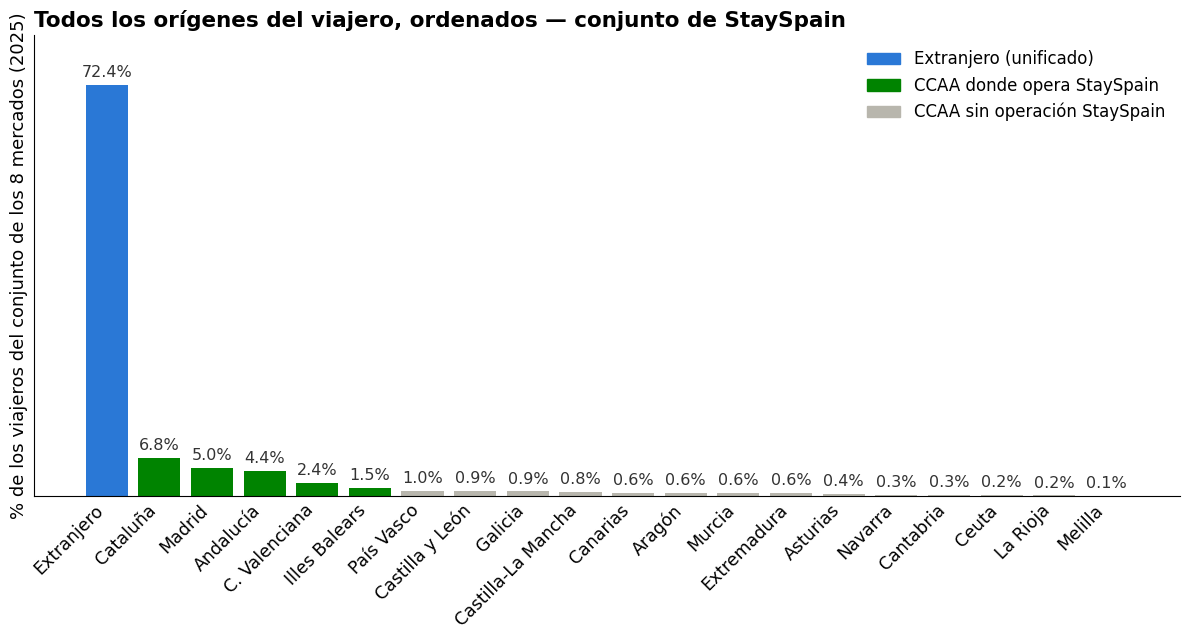

In [10]:
# --- gráfico 2: ranking global de TODOS los orígenes (conjunto de los 8 mercados) ---
def color_origen(o):
    if o == "Extranjero":   return "#2a78d6"    # azul = extranjero unificado
    if o in STAYSPAIN_CCAA: return "#008300"    # verde = CCAA donde opera StaySpain
    return "#b8b6ad"                            # gris = CCAA sin operación StaySpain

glob = P5["Total 8 mercados"].sort_values(ascending=False)    # mayor a menor, izquierda -> derecha
colores = [color_origen(o) for o in glob.index]

fig, ax = plt.subplots(figsize=(12, 6.5))
x = np.arange(len(glob))
ax.bar(x, glob.values, color=colores, width=0.8)
for xi, v in zip(x, glob.values):
    ax.text(xi, v + glob.max() * 0.012, f"{v:.1f}%", ha="center", va="bottom",
            fontsize=11.5, color="#333333")
ax.set_xticks(x)
ax.set_xticklabels(glob.index, rotation=45, ha="right", fontsize=12.5)
ax.set_ylim(0, glob.max() * 1.12)
ax.set_yticks([])                           # los % ya están sobre cada barra
ax.set_ylabel("% de los viajeros del conjunto de los 8 mercados (2025)", fontsize=13)
ax.set_title("Todos los orígenes del viajero, ordenados — conjunto de StaySpain",
             loc="left", fontsize=15.5, weight="bold")
leyenda = [Patch(color="#2a78d6", label="Extranjero (unificado)"),
           Patch(color="#008300", label="CCAA donde opera StaySpain"),
           Patch(color="#b8b6ad", label="CCAA sin operación StaySpain")]
ax.legend(handles=leyenda, loc="upper right", frameon=False, fontsize=12)
for s in ("top", "right"): ax.spines[s].set_visible(False)
ax.tick_params(length=0)
plt.tight_layout(); plt.show()

## 6 · Exportación de resultados a `Results/`

In [11]:
RESULTS = DATA.parent / "Results"
RESULTS.mkdir(exist_ok=True)
kw = dict(sep=";", decimal=",", encoding="utf-8-sig")

P1.to_csv(RESULTS / f"procedencia_mercados_INE_{ANIO}.csv", **kw)
P2.to_csv(RESULTS / f"procedencia_ccaa_INE_{ANIO}.csv", **kw)
P3.to_csv(RESULTS / f"procedencia_origen_nacional_INE_{ANIO}.csv", index=False, **kw)
P5.to_csv(RESULTS / f"procedencia_todos_origenes_INE_{ANIO}.csv", **kw)   # todos los orígenes

print("Exportado a", RESULTS)
for n in ["procedencia_mercados_INE", "procedencia_ccaa_INE",
          "procedencia_origen_nacional_INE", "procedencia_todos_origenes_INE"]:
    print(f"  {n}_{ANIO}.csv")

Exportado a E:\informacion y documentos\Curso analisis de datos IT Academy\Simulador empresarial\ProjecteData\Equip_34\Results
  procedencia_mercados_INE_2025.csv
  procedencia_ccaa_INE_2025.csv
  procedencia_origen_nacional_INE_2025.csv
  procedencia_todos_origenes_INE_2025.csv


---
### Resumen ejecutivo — procedencia del viajero (2025)

- **Todos los mercados son mayoritariamente extranjeros**, pero con grados muy distintos:
  Mallorca y Barcelona rozan el 90 % extranjero, mientras Madrid, Valencia, Sevilla y Málaga
  guardan ~30 % nacional.
- **El origen dominante del conjunto es el extranjero (unificado)**; entre los nacionales
  destacan como emisores transversales **Cataluña, Madrid, Andalucía y la C. Valenciana**.
- **Se ven todos los orígenes**, tanto las CCAA donde StaySpain opera (marcadas `sí`) como las
  que no: el viajero nacional viene sobre todo de su propia comunidad y de los grandes emisores,
  pero cada mercado recibe algo de casi todas.
- Salidas en `Results/procedencia_*_INE_2025.csv` (incluida la tabla completa de orígenes) para
  el deck y Power BI.